In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

In [2]:
# dataset
train="dataset/fruits/train"
test="dataset/fruits/test"

In [4]:
#preprocessing of images for the training
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical' #multiclass - 9fruits
)

Found 359 images belonging to 9 classes.
Found 208 images belonging to 9 classes.


In [7]:
# build a CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(9, activation='softmax')   # 🔥 9 classes
])

C:\Users\Akrit\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# COMPILE MODEL 

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
#train the model
model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.1170 - loss: 2.3352 - val_accuracy: 0.2212 - val_loss: 2.0442
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.2228 - loss: 1.9549 - val_accuracy: 0.4135 - val_loss: 1.6702
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4178 - loss: 1.6228 - val_accuracy: 0.4471 - val_loss: 1.3962
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.4429 - loss: 1.4903 - val_accuracy: 0.5529 - val_loss: 1.2289
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.4763 - loss: 1.3411 - val_accuracy: 0.5721 - val_loss: 1.0945
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5404 - loss: 1.2385 - val_accuracy: 0.6346 - val_loss: 1.0444
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5766 - loss: 1.1449 - val_accuracy: 0.6923 - val_loss: 0.9964
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6100 - loss: 1.0798 - val_accuracy: 0.7019 - val_loss:

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

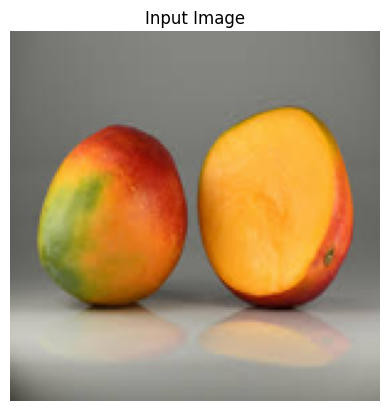

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted: mango fruit


In [13]:
class_names = list(train_data.class_indices.keys())

def predict_image(path):
    img = Image.open(path).convert("RGB").resize((150,150))
    img = np.array(img) / 255.0
    img = img.reshape(1,150,150,3)

    plt.imshow(img[0])
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    pred = model.predict(img)
    index = np.argmax(pred)

    print(f"Predicted: {class_names[index]}")

# Example:
predict_image("mango.jpg")

In [12]:
model.save("model.h5")